<a href="https://colab.research.google.com/github/WenhuiCaii/SEED/blob/Examples/Example_1_Visualize_the_factors_in_SEED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Example for using SEED

Example 1: Visualize variables/sub-indicators

In [ ]:
# Packages installation
!pip install geopandas pandas matplotlib

In [2]:
# Import Packages
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Import spatial boundary and SEED (here use dataset-5 MCR as example)
sa1 = gpd.read_file("/content/Mel_sa1.shp")
seed_5 = pd.read_excel("/content/5-MCR dataset.xlsx")

In [4]:
# Ensure the external key are aligned with each other and are in character
sa1["SA1_CODE21"]  = sa1["SA1_CODE21"].astype(str)
seed_5["SA1_CODE21"] = seed_5["SA1_CODE21"].astype(str)

In [5]:
# Join SEED with spatial boundary
seed_map = sa1.merge(seed_5, on="SA1_CODE21", how="left")

In [6]:
# Make sure the projection is GDA2020/MGA55 (epsg:7855)
# If not, reporject the boundary to GDA2020/MGA55
seed_map_7855 = seed_map.to_crs(epsg=7855)

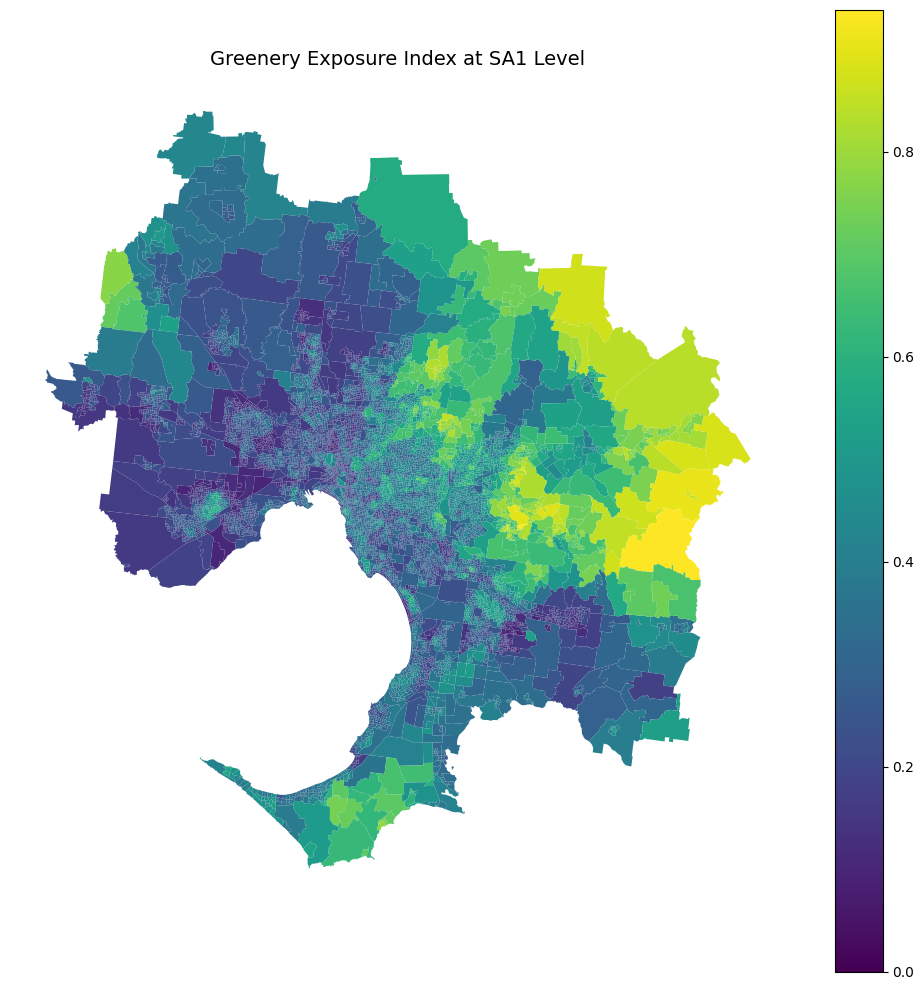

In [7]:
# Visualize one chosen indicator (example: GreeneryExposure)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

seed_map_7855.plot(
    column="GreeneryExposure",   # replace with any SEED indicator
    ax=ax,
    legend=True,
    linewidth=0,
    cmap="viridis"
)

ax.set_title("Greenery Exposure Index at SA1 Level", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()